## Randomized neural networks on Bickley jet

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from contextlib import contextmanager
from matplotlib.animation import FuncAnimation
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'          # or 'sans-serif', 'monospace', etc.
plt.rcParams['font.serif'] = ['Computer Modern Serif'] 

import jax.random as random
import jax.numpy as jnp
import time
from deeptime.data import BickleyJet

import sys
sys.path.append("/home/s2421480/Documents/PhD_first_year/Extended_summer_project/Codes/d3s/")
import ranndy_jax
import importlib
importlib.reload(ranndy_jax)
from ranndy_jax import RaNNDy, VAMPNets
import d3s.domain as domain
plt.ion()

In [2]:
# # Generating dataset

@contextmanager
def nice_plot():
    fig, ax = plt.subplots()
    ax.set_xlabel("$x$", fontsize=30)
    ax.set_ylabel("$y$", fontsize=30)
    ax.set_xticks(np.arange(0, 22, 4))
    ax.set_yticks(np.arange(-3, 4, 2))
    ax.tick_params(axis='x', labelsize=28)
    ax.tick_params(axis='y', labelsize=28)
    ax.axis('auto')
    yield fig, ax
    plt.show()

state = np.random.RandomState(seed=123) 

def draw_initial_positions(n):
    X = np.vstack((state.uniform(0, 20, (n,)),
                   state.uniform(-3, 3, (n, ))))
    return X.T

def forward_transform(X, h=1e-3):
    simulator = BickleyJet(h=h, n_steps=int(1. / h / 10))
    return simulator.trajectory(t0=0, x0=X, length=401)


def psi(x):  # transform the trajectory to periodic 3D trajectory
    return jnp.array([jnp.cos(2*jnp.pi*x[0,:]/20), jnp.sin(2*jnp.pi*x[0,:]/20), x[1,:]/3])


In [3]:
## Simulate the trajectory 

Xinit = draw_initial_positions(15000)
traj = forward_transform(Xinit)
print("Data having {} particles for {} "
      "timesteps in {} dimensions.".format(*traj.shape))

Data having 15000 particles for 401 timesteps in 2 dimensions.


In [4]:
#  Data and Domain

Xa = traj[:, 0].T
Ya = traj[:, -1].T

X = psi(Xa)
Y = psi(Ya)


# define domain
bounds = np.array([[0, 20], [-3, 3]])
boxes = np.array([100, 100])
Omega = domain.discretization(bounds, boxes)

In [5]:
## Run this cell to apply RaNNDy for the forward-backward operator

operator = 'forward_backward'
hidden_sizes = [12000]    
final_size = 128  # Output layer size
activation="relu"  # activation function
init_weights = 'lecun_normal'
init_bias = 'normal'  # Initialization of weights and biases
init_weights_std = 0.5  # Standard deviation for normal initialization
init_bias_std = 0.1  # Scale for uniform initialization
# direct_link=False  # Whether to use direct link to input # TODO:
random_state = 1  # Random state for reproducibility
n_eigfuncs = 9  # Number of eigenfunctions to compute
kwargs = {} # only needed for Hamiltonian operator

ranndy = RaNNDy(
    X=X,
    operator=operator,
    hidden_sizes=hidden_sizes,
    final_size=final_size,
    activation=activation,
    init_weights_dist=init_weights, 
    init_weights_std=init_weights_std,
    init_bias_dist=init_bias,
    init_bias_std=init_bias_std,
    #direct_link=direct_link,
    random_state=random_state
)

## Ensemble models for RaNNDy

n_models = 5
start_time = time.time()
(avg_eigvals, avg_eigfuncs, eigvals_plus, eigvals_minus, eigfuncs_plus, eigfuncs_minus) = ranndy.ensemble_models(n_models=n_models, X=X, Y=Y, Z=None, domain=X, n=n_eigfuncs, epsilon=1e-5)
end_time = time.time()
ensem_time = end_time - start_time
print(f'time for {n_models} ensemble models: ', ensem_time)

/home/s2421480/Documents/Github_projects/ranndy/experiments/ranndy_jax.py:628: ComplexWarning: Casting complex values to real discards the imaginary part
  ensem_eigvals[:, i] = eigvals
/home/s2421480/Documents/Github_projects/ranndy/experiments/ranndy_jax.py:630: ComplexWarning: Casting complex values to real discards the imaginary part
  ensem_eigfuncs[:, :, i] = eigfuncs


time for 5 ensemble models:  21.35358238220215


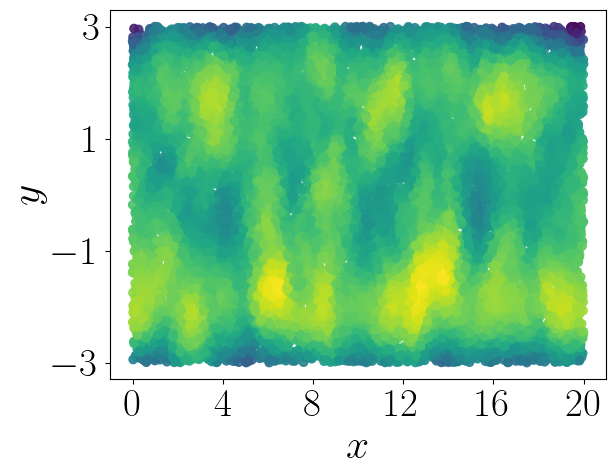

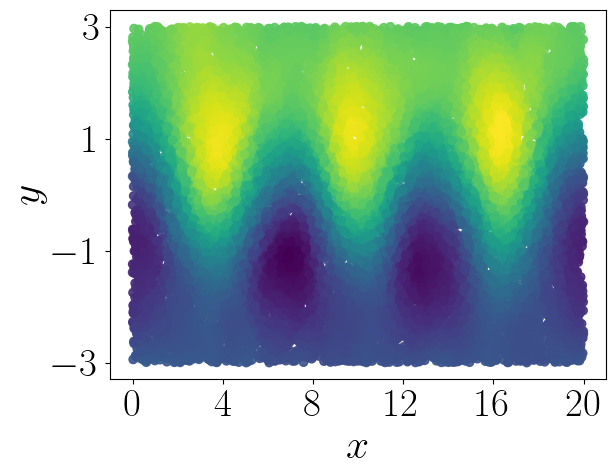

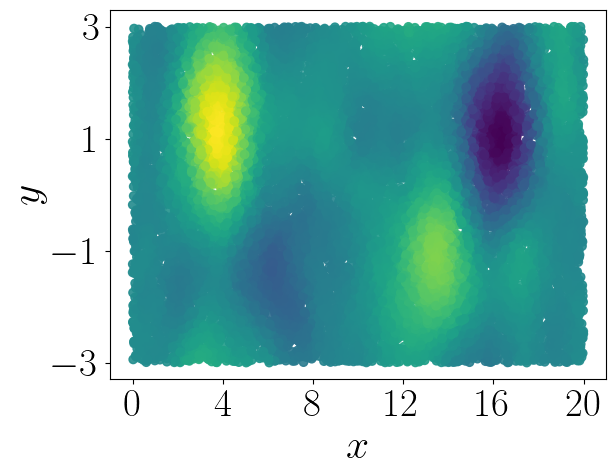

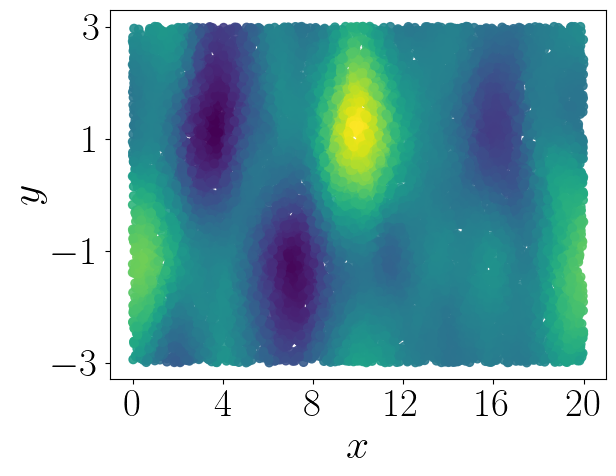

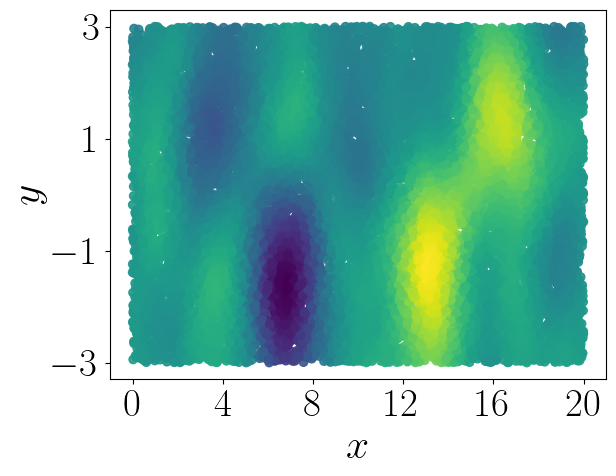

In [6]:
# plot eigenvectors for ranndy

       
for i in range(5):
    #plt.figure(figsize=(3, 2))
    with nice_plot():
        plt.scatter(Xa[0, :], Xa[1, :], c=avg_eigfuncs[i, :], alpha=0.9)

In [13]:
# k-means clustering dominant eigenfunctions
c, l = sp.cluster.vq.kmeans2(np.real(avg_eigfuncs[:9, :]).T, 9, iter=3000)

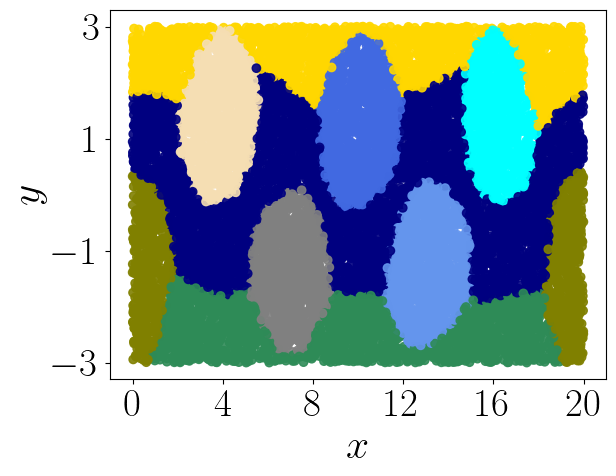

In [14]:
## RaNNDy eigf clustering

cluster_colors = ["aqua", "seagreen", "navy", "gold", "cornflowerblue", "olive", "gray", "wheat", "royalblue"]
cols = [cluster_colors[label] for label in l]

with nice_plot() as (fig, ax):
    ax.scatter(Xa[0, :], Xa[1, :], c=cols, alpha=0.9)
    #fig.savefig('/home/s2421480/Documents/PhD_third_year/rnn_closed_notebooks/figures/bickley_eigf_clusters.png', bbox_inches='tight', dpi=300)



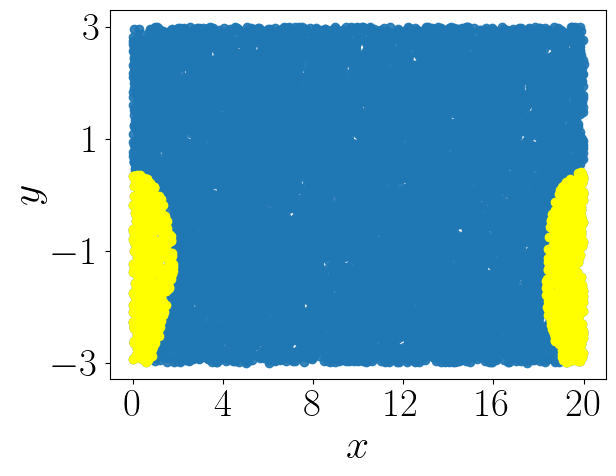

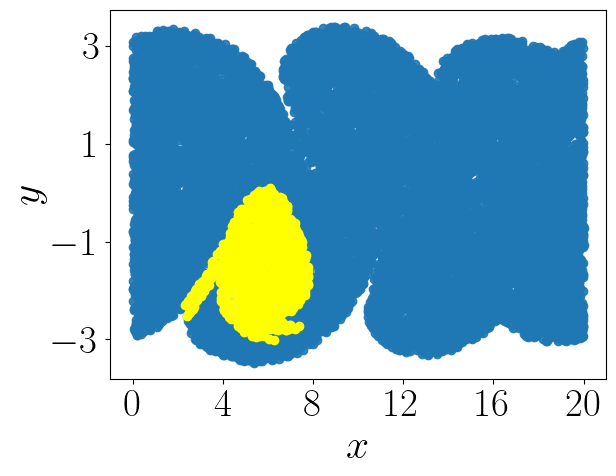

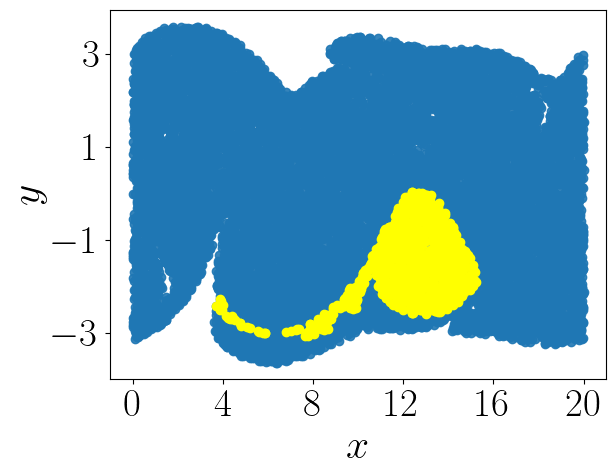

In [17]:
# plot few snapshots

timesteps = [0, 25, 50]  # pick any timesteps
#fig, axes = plt.subplots(1, len(timesteps), figsize=(15,4))

co_indices = np.where(l == 5)[0]
for t in timesteps:
    with nice_plot() as (fig, ax):
        ax.scatter(traj[:, t, 0], traj[:, t, 1], alpha=0.9)
        ax.scatter(traj[co_indices, t, 0], traj[co_indices, t, 1], c="yellow",  marker="o")
        #fig.savefig(f'/home/s2421480/Documents/PhD_third_year/rnn_closed_notebooks/figures/bickley_timestep_{t}.png', bbox_inches='tight', dpi=300)